Virtual Acoustics and Immersive Audio Workshop - CCRMA Stanford University  
28.07.25 - Orchisama Das, Gloria Dal Santo
  
### L06: Binaural rendering

In this assignment we will 
- Analyze a given HRIR dataset in SOFA format
- Interpolate the HRIRs to a denser grid and save it in SOFA format
- Listen and compare both datasets in Reaper with SPARTA's binauralizer plugin with head tracking.

In [2]:
pip install loguru

   ---------------------------------------- 0.0/61.6 kB ? eta -:--:--
   ---------------------------------------- 61.6/61.6 kB 3.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
from pathlib import Path

# 將 src/ 加入 Python 模組搜尋路徑
sys.path.append(str(Path().resolve().parent / "src"))

In [7]:
pip install spaudiopy

^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from pathlib import Path
from loguru import logger
import matplotlib.pyplot as plt
from spatial_audio.sofa_parser import HRIRReader, HRIRWriter
from spatial_audio.hrtf import HRIRInterpolator, HRIRSet
from spatial_audio.plot import plot_points_on_sphere
from utils import unpack_coordinates, cart2sph

## Part 1
- Read the HRTF dataset with `HRIRReader`
- Plot the azimuth and elevation angles at which the HRIRs were measured on a spherical grid with the `spatial_audio.plot.plot_points_on_sphere()` function.
- Note the grid spacing between azimuth angles ($\theta_\text{grid}$) and elevation angles ($\phi_\text{grid}$). Verify that the grid is equiangular (same spacing between all azimuth and elevation angles).

2025-07-28 15:24:59.076 | INFO     | spatial_audio.sofa_parser:__init__:41 - None
2025-07-28 15:24:59.076 | INFO     | spatial_audio.sofa_parser:__init__:42 - Shape of the IRs is (684, 2, 200)


R = 2 receiver (set by ReceiverPosition of dimension RCI, RCM)
E = 1 emitter (set by EmitterPosition of dimension ECI, ECM)
M = 684 measurements (set by Data_IR of dimension MRN)
N = 200 samples (set by Data_IR of dimension MRN)
C = 3 coordinate dimensions, fixed
I = 1 single dimension, fixed
S = 0 maximum string length

Azimuth grid spacing θ_grid: [10.]
Elevation grid spacing φ_grid: [10.]


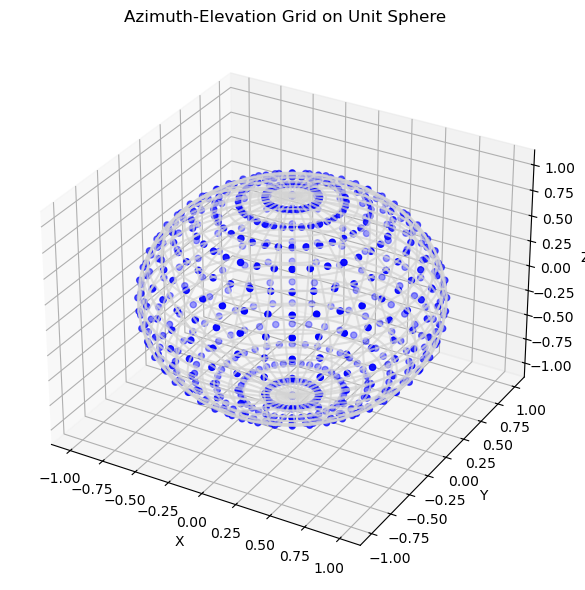

In [4]:
# Path to HRIR dataset
sofa_path = Path('../data/Week 2/hrtf/CIPIC_subject_119_equiangular_grid.sofa').resolve()

#### WRITE YOUR CODE HERE ####

# Create HRIRReader object
hrir_reader = HRIRReader(sofa_path)

# Read azimuth and elevation angles from the dataset
#source_positions = reader.get_source_view(coord_type="spherical")
source_positions = hrir_reader.listener_view
azimuths = source_positions[:, 0]
elevations = source_positions[:, 1]

# Plot the azimuth and elevation angles on a sphere by calling plot_points_on_sphere
az_spacing = np.unique(np.round(np.diff(np.sort(np.unique(azimuths))), 2))
el_spacing = np.unique(np.round(np.diff(np.sort(np.unique(elevations))), 2))
print(f"Azimuth grid spacing θ_grid: {az_spacing}")
print(f"Elevation grid spacing φ_grid: {el_spacing}")

plot_points_on_sphere(azimuths, elevations)

In [5]:
# 確保 azimuths, elevations 是 numpy array（若未轉型）
azimuths = np.asarray(azimuths)
elevations = np.asarray(elevations)

# 找出唯一的角度，排序後取差值
unique_az = np.sort(np.unique(azimuths))
unique_el = np.sort(np.unique(elevations))

# 差值並四捨五入至小數第2位
az_spacing = np.round(np.diff(unique_az), 2)
el_spacing = np.round(np.diff(unique_el), 2)

# 顯示唯一間距
print("Azimuth grid spacing θ_grid:", np.unique(az_spacing))
print("Elevation grid spacing φ_grid:", np.unique(el_spacing))

Azimuth grid spacing θ_grid: [10.]
Elevation grid spacing φ_grid: [10.]


In [6]:
print("azimuths shape:", azimuths.shape)
print("elevations shape:", elevations.shape)
print("azimuths unique values:", np.unique(azimuths))
print("elevations unique values:", np.unique(elevations))

azimuths shape: (684,)
elevations shape: (684,)
azimuths unique values: [-180. -170. -160. -150. -140. -130. -120. -110. -100.  -90.  -80.  -70.
  -60.  -50.  -40.  -30.  -20.  -10.    0.   10.   20.   30.   40.   50.
   60.   70.   80.   90.  100.  110.  120.  130.  140.  150.  160.  170.]
elevations unique values: [-90. -80. -70. -60. -50. -40. -30. -20. -10.   0.  10.  20.  30.  40.
  50.  60.  70.  80.  90.]


In [8]:
print("listener_view shape:", hrir_reader.listener_view.shape)

listener_view shape: (684, 3)


### Part 2

See `src/spatial_audio/hrtf.py`. Create an `HRIRSet` dataclass from the dataset you have just read.

In [9]:
hrir_data = HRIRSet(hrir_reader.fs, hrir_reader.num_meas, hrir_reader.ir_length, hrir_reader.ir_data,
                    hrir_reader.listener_view, hrir_reader.listener_view_type, source_view=hrir_reader.get_source_view("spherical"))

In [10]:
print("HRIR shape:", hrir_data.hrir_data.shape)
print("Listener view shape:", hrir_data.listener_view.shape)
print("Source view shape:", hrir_data.source_view.shape)
print("Sampling rate:", hrir_data.fs)

HRIR shape: (684, 2, 200)
Listener view shape: (684, 3)
Source view shape: (1, 3)
Sampling rate: 44100.0


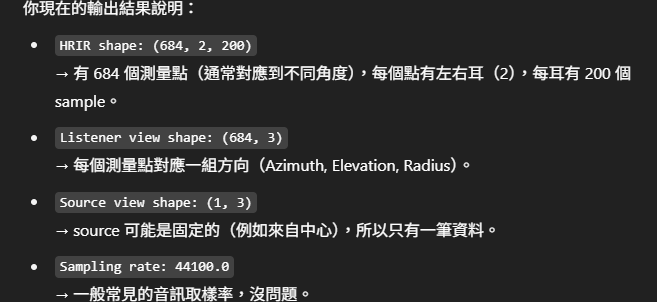

### Part 3

- Complete the function `bilinear_interpolation(new_az_res: float, new_el_res: float)` in the `HRIRInterpolator` class to interpolate the HRIRs on the new grid.
- The new grid should have a spacing of $2^\circ$ between azimuth angles and $5^\circ$ between elevation angles. This should return an object of type `HRIRSet`. 

Recall the formula for the bilinear interpolation of HRIRs,

\begin{aligned}
\hat{h}(k) &= \left(1-c_\theta\right)\left(1-c_\phi\right) h_a(k)+c_\theta\left(1-c_\phi\right) h_b(k)+ \\
&+c_\theta c_\phi h_c(k)+\left(1-c_\theta\right) c_\phi h_d(k), \\
c_\theta &= \frac{\theta \ \text{mod} \ \theta_\text{grid}}{\theta_\text{grid}}, \quad c_\phi = \frac{\phi \ \text{mod} \ \phi_\text{grid}}{\phi_\text{grid}}
\end{aligned}
where $h_a, h_b, h_c, h_d$ are the adjacent HRIRs to a new angle-pair $(\theta, \phi)$. Hint: the grid of HRIRs provided has uniform spacing between all azimuth and elevation angles.

In [12]:
#### WRITE YOUR CODE HERE ####

# Create HRIRInterpolator object
interpolator = HRIRInterpolator(hrir_data)

# Call bilinear_interpolation function with azimuth and elevation grid spacing angles
new_hrir_set = interpolator.bilinear_interpolation(new_az_res=2.0, new_el_res=5.0)

100%|██████████| 6697/6697 [00:00<00:00, 42423.01it/s]


In [13]:
# 確認 shape（optional）
print("New HRIR shape:", new_hrir_set.hrir_data.shape)
print("New listener view shape:", new_hrir_set.listener_view.shape)

New HRIR shape: (6697, 2, 200)
New listener view shape: (6697, 3)


### Part 5

Save the new densely sampled dataset to SOFA format using `HRIRWriter`.

In [15]:
new_sofa_path =  Path('../data/Week 2/hrtf/densely_sampled_CIPIC_subject_119.sofa').resolve()

#### WRITE YOUR CODE HERE ####

# Create HRIRWriter object, set_list_view_as_source_pos should be True
writer = HRIRWriter(new_hrir_set, set_list_view_as_source_pos=True)
# Save to new_sofa_path
writer.write_to_file(str(new_sofa_path))

### Part 6

Test if SOFA file saving worked properly. Plot an HRIR from the original dataset and the closest HRIR from the new dataset.

2025-07-28 15:31:03.742 | INFO     | spatial_audio.sofa_parser:__init__:41 - None
2025-07-28 15:31:03.742 | INFO     | spatial_audio.sofa_parser:__init__:42 - Shape of the IRs is (6697, 2, 200)


R = 2 receiver (set by ReceiverPosition of dimension RCI, RCM)
E = 1 emitter (set by EmitterPosition of dimension ECI, ECM)
M = 6697 measurements (set by Data_IR of dimension MRN)
N = 200 samples (set by Data_IR of dimension MRN)
C = 3 coordinate dimensions, fixed
I = 1 single dimension, fixed
S = 0 maximum string length



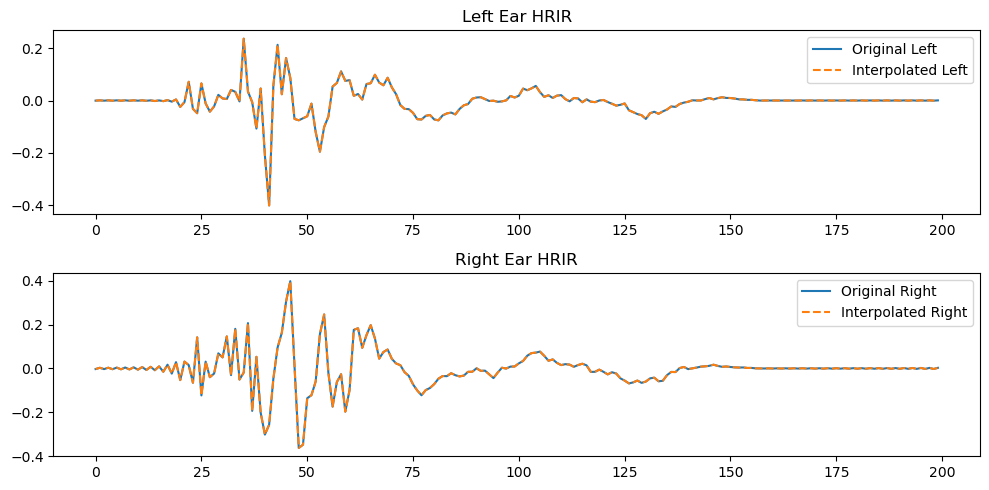

In [16]:
# Create HRIRReader object and plot an HRIR
new_hrir_reader = HRIRReader(new_sofa_path)

# Plot HRIRs for sanity check

# Choose an index to compare (e.g., the first measurement)
idx = 0

# Get the original HRIR (before interpolation)
old_hrir = hrir_data.hrir_data[idx, :, :]  # shape: (2, 200)

# Get the new HRIR (after interpolation and saving)
new_hrir = new_hrir_reader.ir_data[idx, :, :]  # shape: (2, 200)

# Plot and compare HRIRs for both ears
fig, axs = plt.subplots(2, 1, figsize=(10, 5))

# Plot left ear
axs[0].plot(old_hrir[0], label='Original Left')
axs[0].plot(new_hrir[0], label='Interpolated Left', linestyle='--')
axs[0].legend()
axs[0].set_title('Left Ear HRIR')

# Plot right ear
axs[1].plot(old_hrir[1], label='Original Right')
axs[1].plot(new_hrir[1], label='Interpolated Right', linestyle='--')
axs[1].legend()
axs[1].set_title('Right Ear HRIR')

plt.tight_layout()
plt.show()